In [368]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [369]:
df = pd.read_csv('Employee.csv')
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [370]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [371]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [372]:
df.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [373]:
df.duplicated().sum()

np.int64(1889)

In [374]:
df[df.duplicated()]

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
111,Bachelors,2017,Pune,2,27,Female,No,5,1
130,Bachelors,2017,Bangalore,3,26,Female,No,4,0
138,Bachelors,2017,New Delhi,3,28,Male,No,2,0
160,Bachelors,2014,Bangalore,3,28,Female,No,3,0
167,Bachelors,2014,Bangalore,3,25,Male,No,3,0
...,...,...,...,...,...,...,...,...,...
4640,Bachelors,2015,Bangalore,3,35,Male,No,0,0
4642,Bachelors,2012,Bangalore,3,36,Female,No,4,0
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0


In [375]:
df.drop_duplicates(inplace=True)

In [376]:
df['LeaveOrNot'].unique()

array([0, 1])

In [377]:
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].unique()}")

Unique values in 'Education': ['Bachelors' 'Masters' 'PHD']
Unique values in 'JoiningYear': [2017 2013 2014 2016 2015 2012 2018]
Unique values in 'City': ['Bangalore' 'Pune' 'New Delhi']
Unique values in 'PaymentTier': [3 1 2]
Unique values in 'Age': [34 28 38 27 24 22 23 37 32 39 29 30 36 31 25 26 40 35 33 41]
Unique values in 'Gender': ['Male' 'Female']
Unique values in 'EverBenched': ['No' 'Yes']
Unique values in 'ExperienceInCurrentDomain': [0 3 2 5 1 4 7 6]
Unique values in 'LeaveOrNot': [0 1]


In [378]:
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    print(f"Value counts for '{column}':\n{df[column].value_counts()}\n")

Value counts for 'Education':
Education
Bachelors    1971
Masters       637
PHD           156
Name: count, dtype: int64

Value counts for 'City':
City
Bangalore    1171
Pune          801
New Delhi     792
Name: count, dtype: int64

Value counts for 'Gender':
Gender
Male      1529
Female    1235
Name: count, dtype: int64

Value counts for 'EverBenched':
EverBenched
No     2403
Yes     361
Name: count, dtype: int64



In [379]:
df['LeaveOrNot'].value_counts(
    
)

LeaveOrNot
0    1676
1    1088
Name: count, dtype: int64

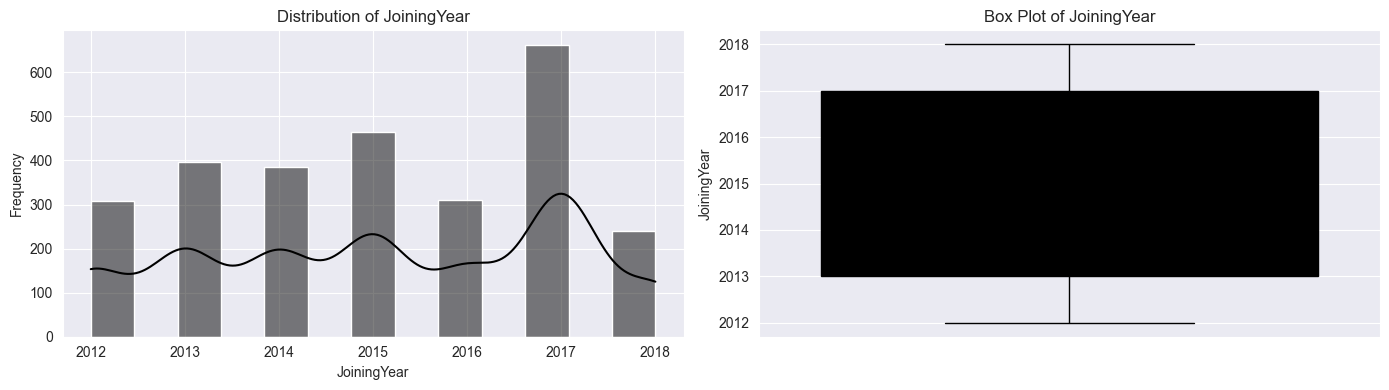

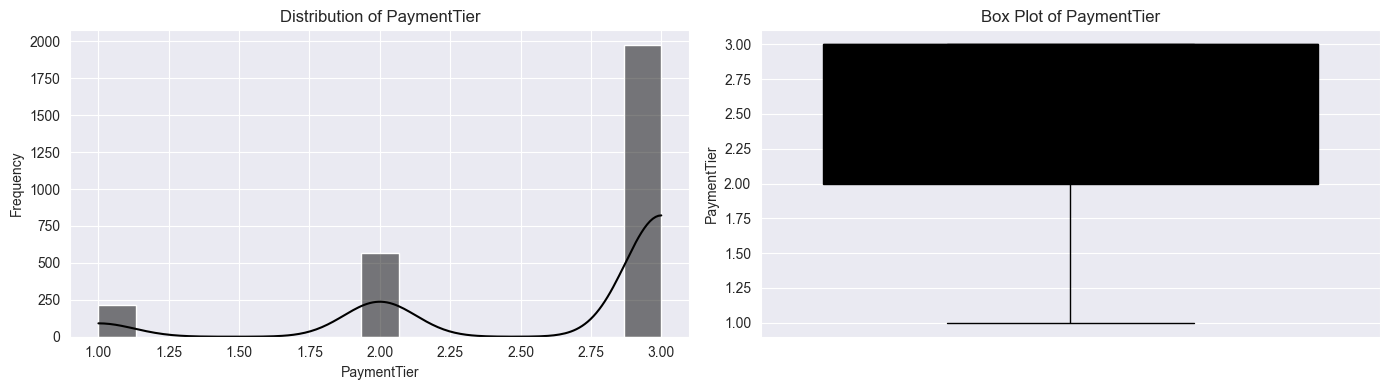

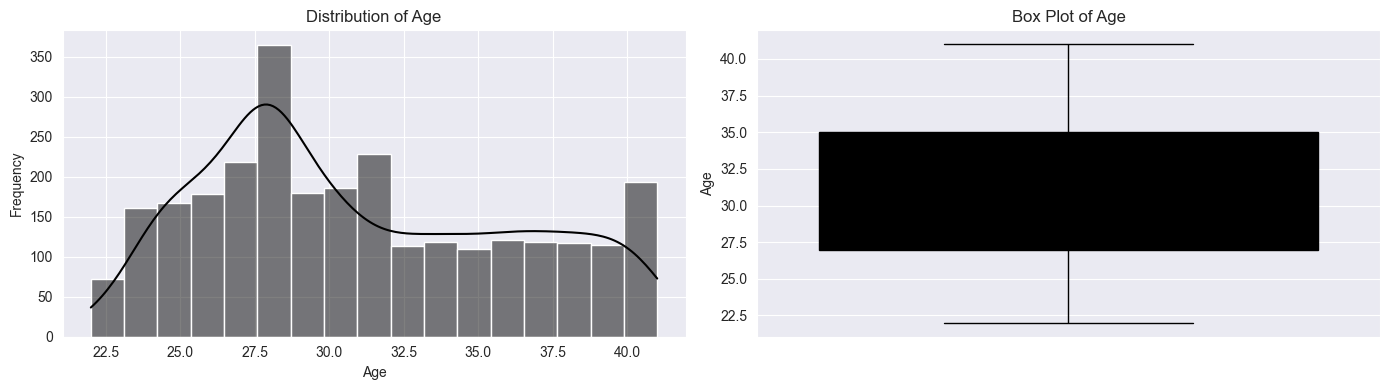

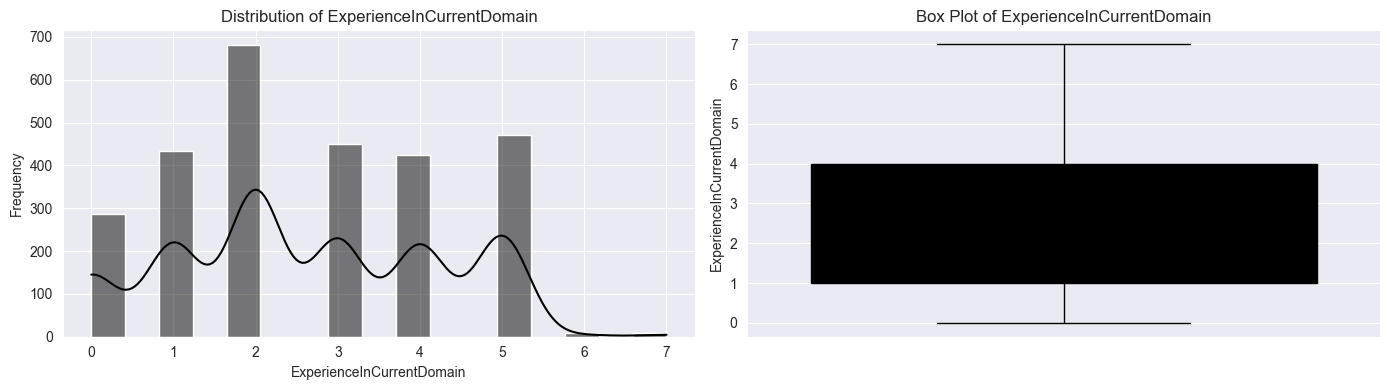

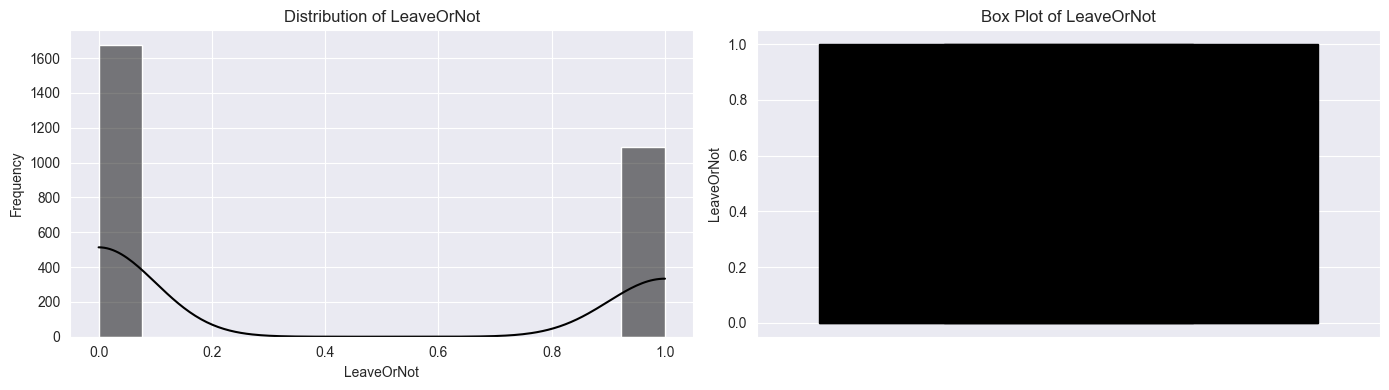

In [380]:
sns.set_style("darkgrid")
numeric_columns = df.select_dtypes(include=[np.number]).columns
for column in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    
    sns.histplot(df[column], kde=True, ax=axes[0], color='black')
    axes[0].set_title(f'Distribution of {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')
    
    
    sns.boxplot(df[column], ax=axes[1], color='black')
    axes[1].set_title(f'Box Plot of {column}')
    axes[1].set_ylabel(column)
    
    plt.tight_layout()
    plt.show()

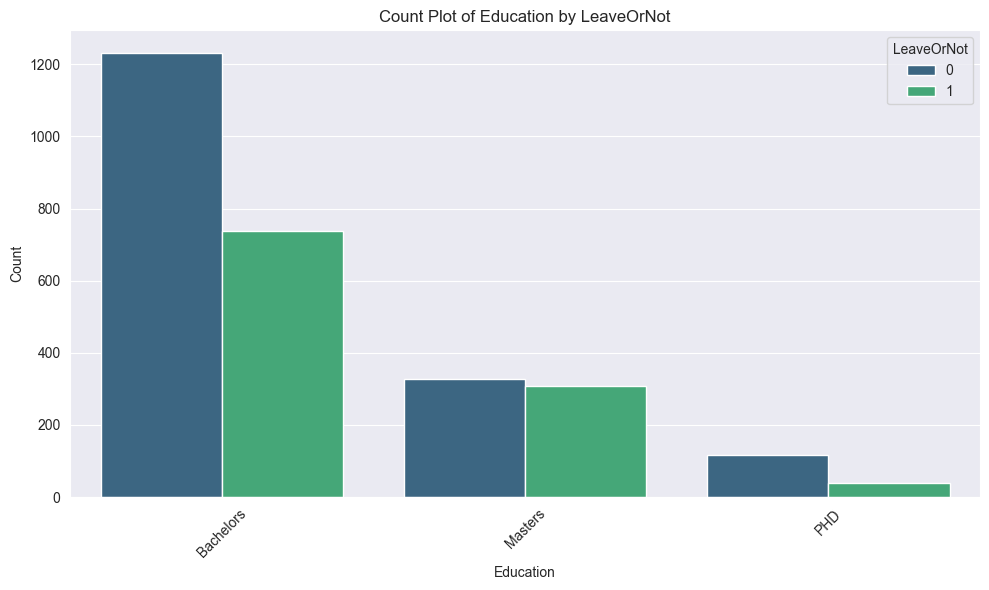

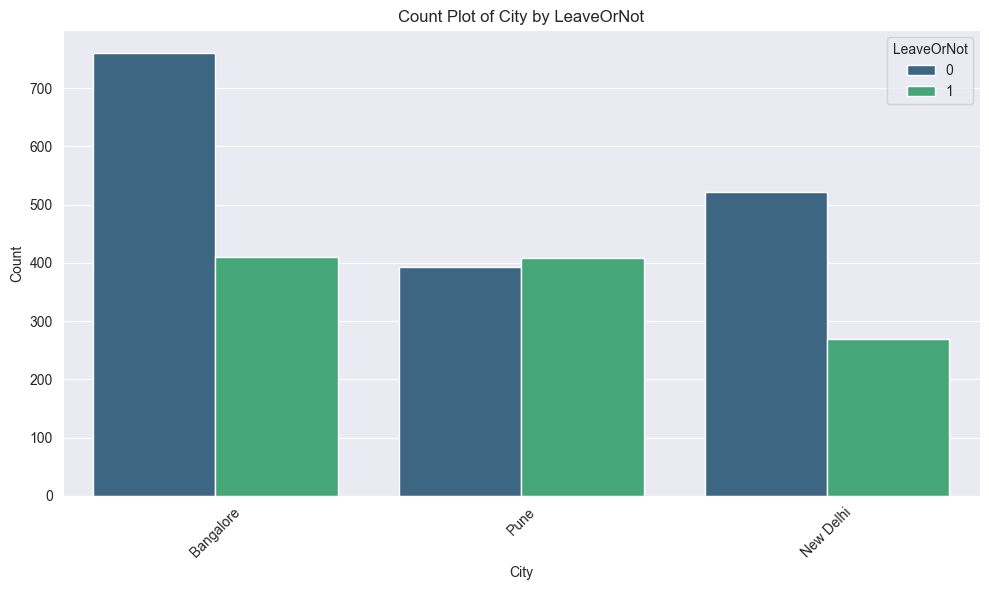

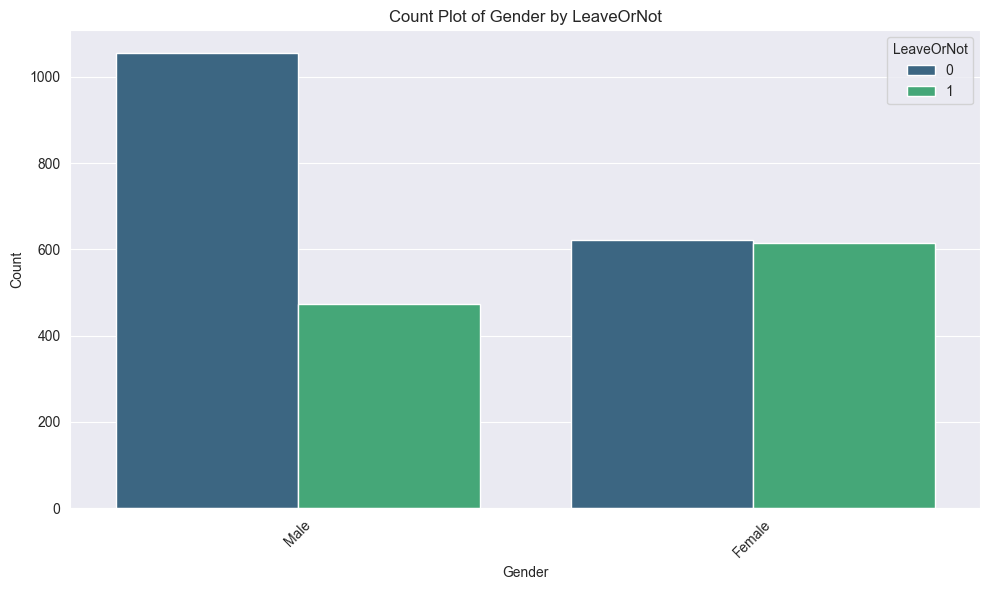

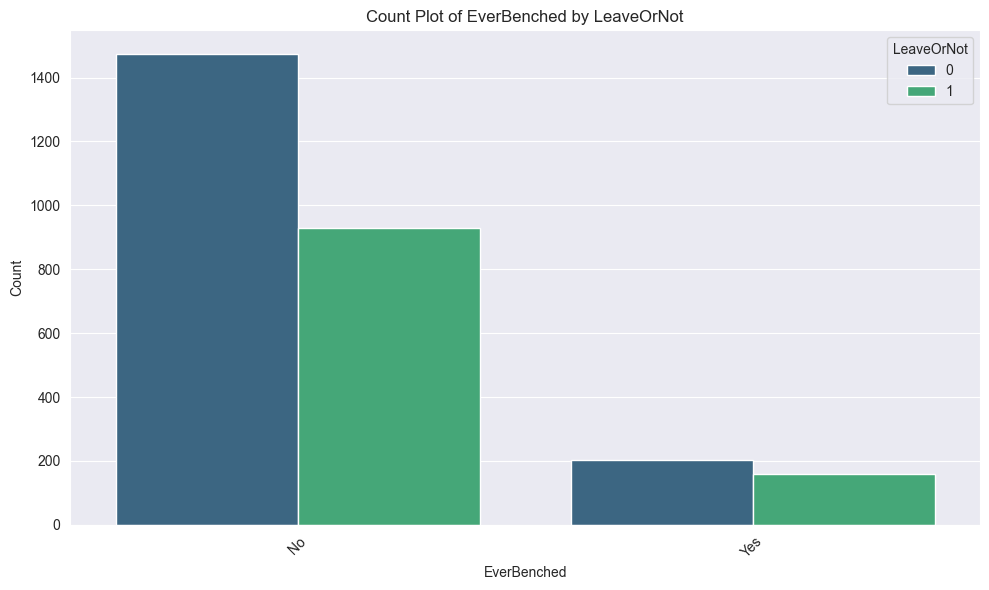

In [381]:

for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, hue='LeaveOrNot', palette='viridis')
    plt.title(f'Count Plot of {column} by LeaveOrNot')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='LeaveOrNot')
    plt.tight_layout()
    plt.show()

C:\Users\workstation\AppData\Local\Temp\ipykernel_15512\4151581527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PaymentTier', y='Age', palette='viridis')


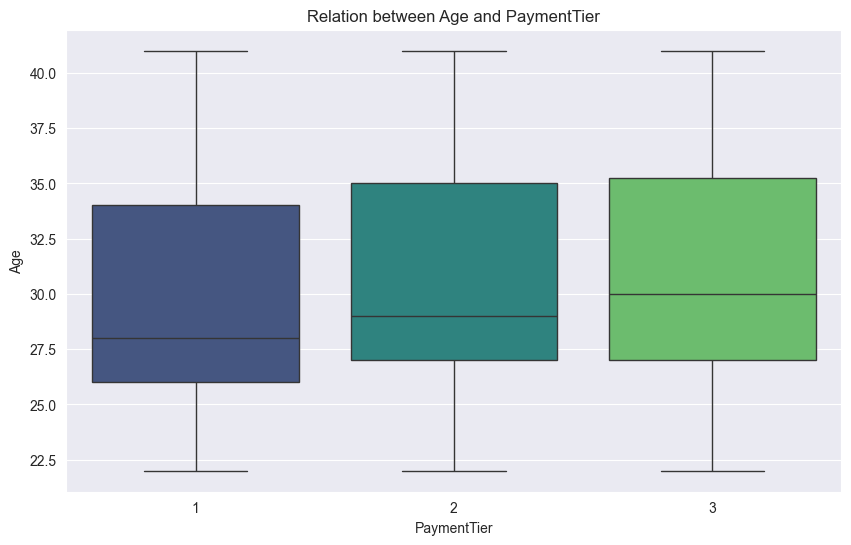

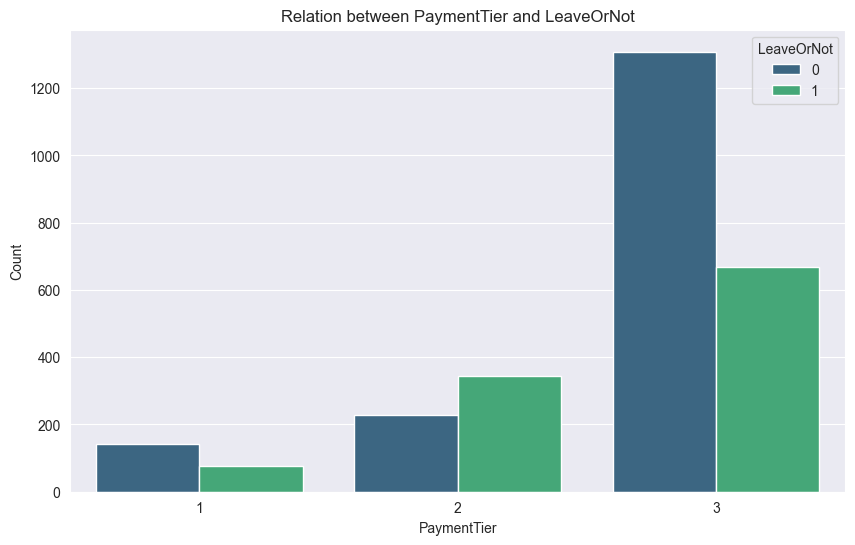

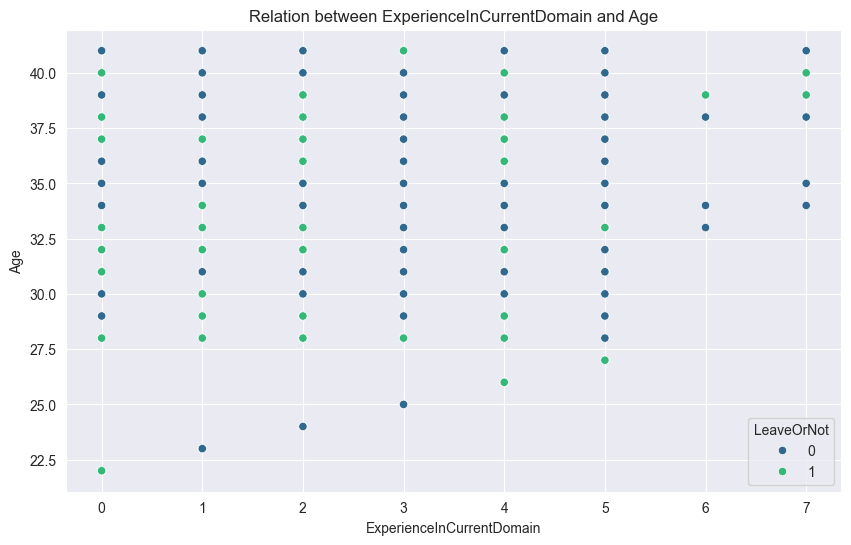

In [382]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PaymentTier', y='Age', palette='viridis')
plt.title('Relation between Age and PaymentTier')
plt.xlabel('PaymentTier')
plt.ylabel('Age')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentTier', hue='LeaveOrNot', palette='viridis')
plt.title('Relation between PaymentTier and LeaveOrNot')
plt.xlabel('PaymentTier')
plt.ylabel('Count')
plt.legend(title='LeaveOrNot')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ExperienceInCurrentDomain', y='Age', hue='LeaveOrNot', palette='viridis')
plt.title('Relation between ExperienceInCurrentDomain and Age')
plt.xlabel('ExperienceInCurrentDomain')
plt.ylabel('Age')
plt.legend(title='LeaveOrNot')
plt.show()

In [383]:
df["YearsInCompany"] = 2025 - df["JoiningYear"]

In [384]:
df["Age_Experience"] = df["Age"] * df["ExperienceInCurrentDomain"]

In [385]:
df["Age_per_Experience"] = df["Age"] / (df["ExperienceInCurrentDomain"] + 1)

In [386]:
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,YearsInCompany,Age_Experience,Age_per_Experience
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,8,0,34.000000
1,Bachelors,2013,Pune,1,28,Female,No,3,1,12,84,7.000000
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,11,76,12.666667
3,Masters,2016,Bangalore,3,27,Male,No,5,1,9,135,4.500000
4,Masters,2017,Pune,3,24,Male,Yes,2,1,8,48,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4645,Masters,2017,Pune,2,31,Female,No,2,0,8,62,10.333333
4647,Bachelors,2016,Pune,3,30,Male,No,2,0,9,60,10.000000
4649,Masters,2013,Pune,2,37,Male,No,2,1,12,74,12.333333
4650,Masters,2018,New Delhi,3,27,Male,No,5,1,7,135,4.500000


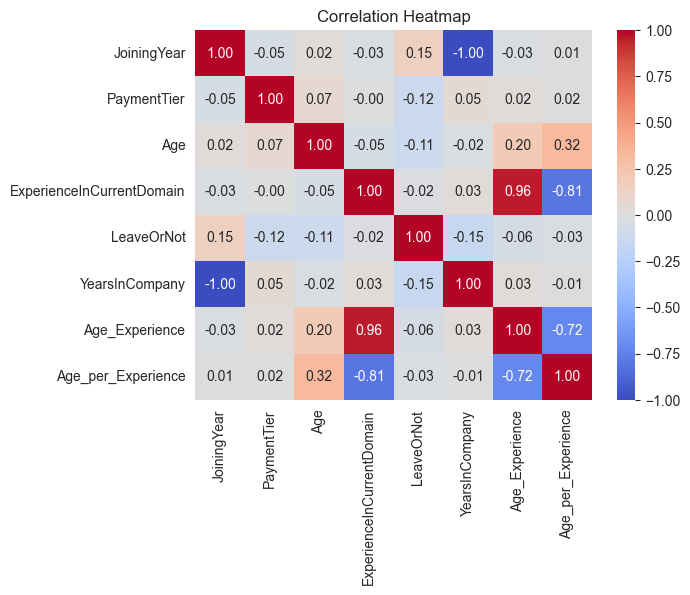

In [387]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df['Gender']=df['Gender'].map({'Male': 1, 'Female': 0})
df['EverBenched']=df['EverBenched'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['City','Education'], drop_first=True)

In [389]:
df.head()

,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,YearsInCompany,Age_Experience,Age_per_Experience,City_New Delhi,City_Pune,Education_Masters,Education_PHD
0,2017,3,34,1,0,0,0,8,0,34.000000,False,False,False,False
1,2013,1,28,0,0,3,1,12,84,7.000000,False,True,False,False
2,2014,3,38,0,0,2,0,11,76,12.666667,True,False,False,False
3,2016,3,27,1,0,5,1,9,135,4.500000,False,False,True,False
4,2017,3,24,1,1,2,1,8,48,8.000000,False,True,True,False


In [390]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 0 to 4651
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   JoiningYear                2764 non-null   int64  
 1   PaymentTier                2764 non-null   int64  
 2   Age                        2764 non-null   int64  
 3   Gender                     2764 non-null   int64  
 4   EverBenched                2764 non-null   int64  
 5   ExperienceInCurrentDomain  2764 non-null   int64  
 6   LeaveOrNot                 2764 non-null   int64  
 7   YearsInCompany             2764 non-null   int64  
 8   Age_Experience             2764 non-null   int64  
 9   Age_per_Experience         2764 non-null   float64
 10  City_New Delhi             2764 non-null   bool   
 11  City_Pune                  2764 non-null   bool   
 12  Education_Masters          2764 non-null   bool   
 13  Education_PHD              2764 non-null   bool   
dt

In [391]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

X = df.drop('LeaveOrNot', axis=1)
y = df['LeaveOrNot']

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])


param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1, 0.1, 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1'   
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)



Best Params: {'svc__C': 100, 'svc__gamma': 0.01}


In [396]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.93      0.87       335
           1       0.86      0.67      0.75       218

    accuracy                           0.83       553
   macro avg       0.84      0.80      0.81       553
weighted avg       0.83      0.83      0.82       553



In [393]:
print(confusion_matrix(y_test, y_pred))

[[312  23]
 [ 72 146]]


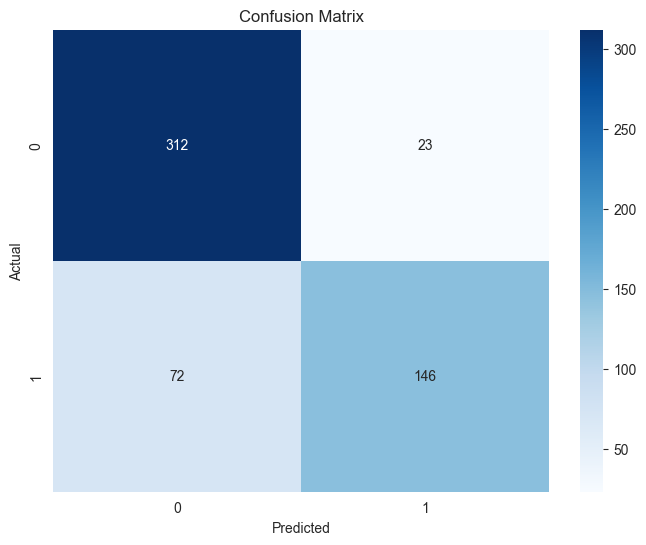

In [394]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9,11,20,50,100],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring='f1'
)

grid_knn.fit(x_train, y_train)

print("KNN Best Params:", grid_knn.best_params_)

KNN Best Params: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}


In [400]:
best_model2 = grid_knn.best_estimator_

y_pred = best_model2.predict(x_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.79      0.82      0.80       335
           1       0.70      0.66      0.68       218

    accuracy                           0.76       553
   macro avg       0.74      0.74      0.74       553
weighted avg       0.75      0.76      0.75       553



In [411]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='f1'
)

grid_rf.fit(x_train, y_train)

print("Random Forest Best Params:", grid_rf.best_params_)


Random Forest Best Params: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


In [414]:
best_model_rf = grid_rf.best_estimator_
y_pred = best_model_rf.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       335
           1       0.83      0.64      0.72       218

    accuracy                           0.80       553
   macro avg       0.81      0.78      0.79       553
weighted avg       0.81      0.80      0.80       553

[[306  29]
 [ 79 139]]


Text(50.722222222222214, 0.5, 'Actual')

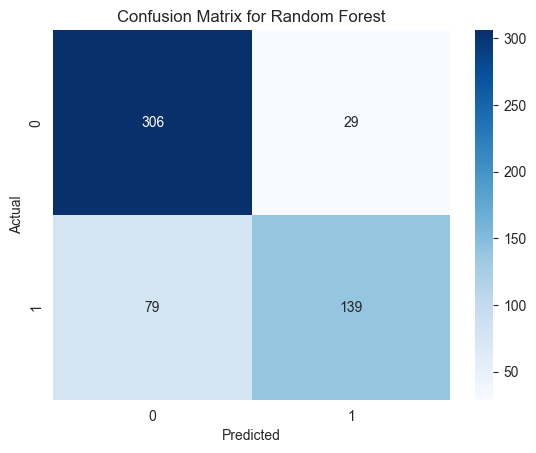

In [415]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')